In [160]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

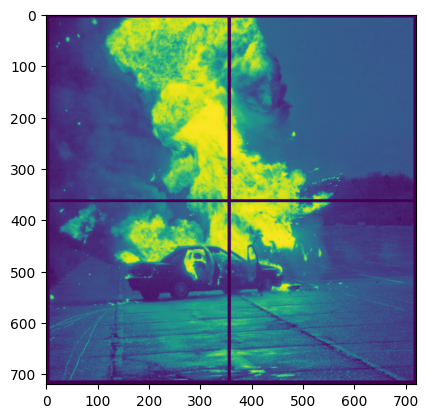

In [161]:
duar1 = cv.imread("Meledak.png", cv.IMREAD_GRAYSCALE)
plt.imshow(duar1)

Text(0.5, 1.0, 'part 4')

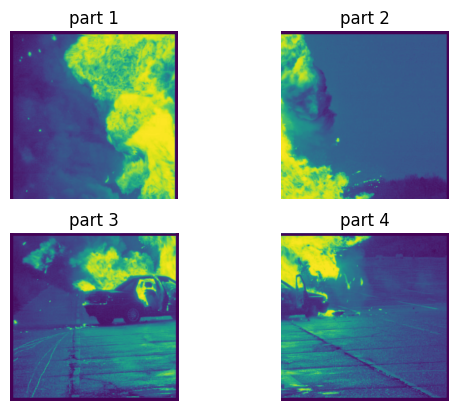

In [162]:
def slicing_4(gambar):
    h, w = gambar.shape[:2]  
    h_mid = h // 2
    w_mid = w // 2
    kiri_atas = gambar[:h_mid, :w_mid]
    kanan_atas = gambar[:h_mid, w_mid:]
    kiri_bawah = gambar[h_mid:, :w_mid]
    kanan_bawah = gambar[h_mid:, w_mid:]
    return kiri_atas, kanan_atas, kiri_bawah, kanan_bawah
d1, d2, d3, d4 = slicing_4(duar1)
plt.subplot(2,2,1)
plt.imshow(d1)
plt.axis('off')
plt.title('part 1')

plt.subplot(2,2,2)
plt.imshow(d2)
plt.axis('off')
plt.title('part 2')

plt.subplot(2,2,3)
plt.imshow(d3)
plt.axis('off')
plt.title('part 3')

plt.subplot(2,2,4)
plt.imshow(d4)
plt.axis('off')
plt.title('part 4')

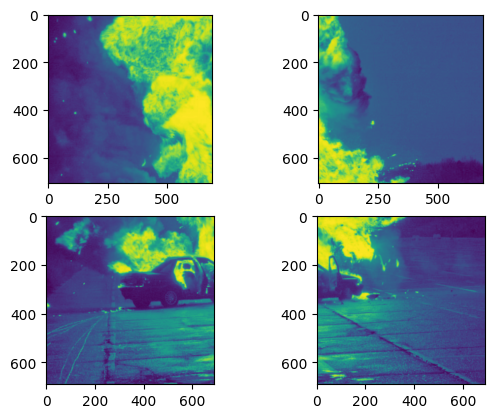

In [163]:
def dilatasi(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape
    dilated = np.zeros((h * 2, w * 2), dtype=image.dtype)
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y][x] = image[int(y / 2)][int(x / 2)]
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2)
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4)
    return dilated[sy:ey, sx:ex]

d1a=dilatasi(d1, 15,0,15,15)
d2a=dilatasi(d2, 15,0,15,15)
d3a=dilatasi(d3, 15,15,15,15)
d4a=dilatasi(d4, 15,15,15,15)
plt.subplot(2,2,1)
plt.imshow(d1a)
plt.subplot(2,2,2)
plt.imshow(d2a)
plt.subplot(2,2,3)
plt.imshow(d3a)
plt.subplot(2,2,4)
plt.imshow(d4a)

(np.float64(-0.5), np.float64(1379.5), np.float64(1394.5), np.float64(-0.5))

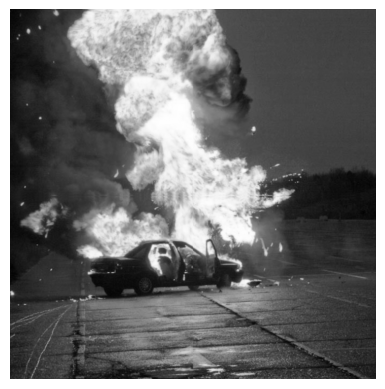

In [164]:
def merge_h(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = max(c1.shape[0], c2.shape[0])
    lebar = c1.shape[1] + c2.shape[1]
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[0:c2.shape[0], c1.shape[1]:] = c2
    return hasil
def merge_v(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = c1.shape[0] + c2.shape[0]
    lebar = max(c1.shape[1], c2.shape[1])
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil

atas1 = merge_h(d1a,d2a)
bawah1 = merge_h(d3a, d4a)
duar2 = merge_v(atas1,bawah1)
plt.imshow(duar2, cmap="gray")
plt.axis('off')

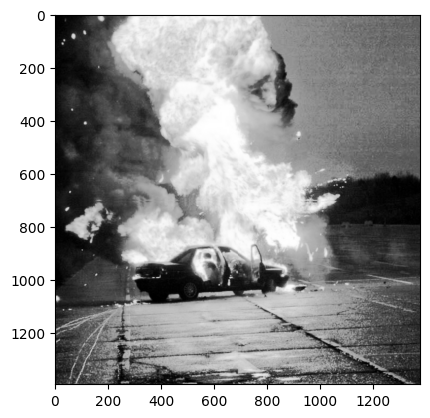

In [165]:
def ekualisasi(image):
    hist = np.zeros(256, dtype=int)
    height, width = image.shape
    for i in range(height):
        for j in range(width):
            val = image[i, j]
            hist[val] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(hist[0:i+1])

    hasil = np.round(((cdf * 255) / (height * width))).astype(np.uint8)

    equalized_img = np.zeros_like(image)
    for i in range(height):
        for j in range(width):
            equalized_img[i, j] = hasil[image[i, j]]

    return equalized_img

duar2e = ekualisasi(duar2)
plt.imshow(duar2e, cmap ="gray")

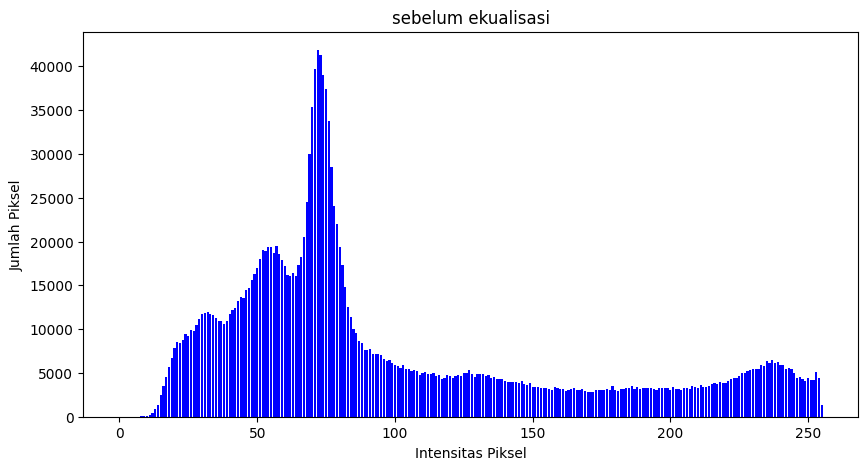

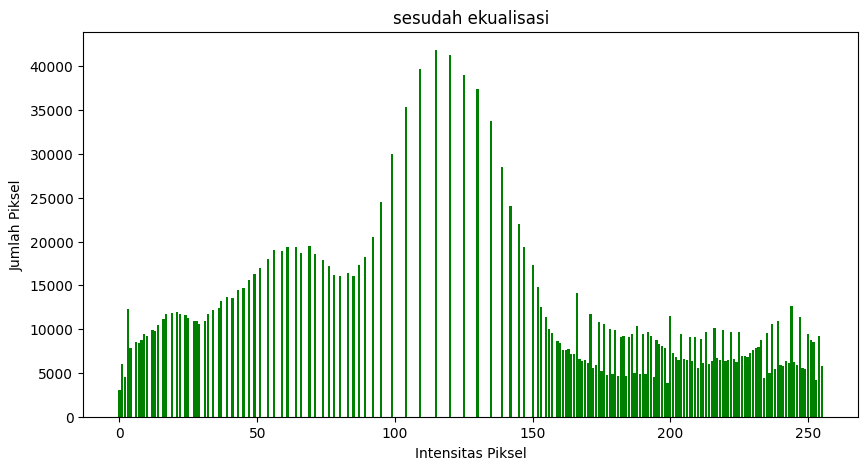

In [166]:
def buat_hist(citra):
    histogram = [0] * 256
    height = len(citra)
    width = len(citra[0]) if height > 0 else 0
    for i in range(height):
        for j in range(width):
            val = int(citra[i][j]) 
            histogram[val] += 1 
    return histogram
def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8)
    plt.show()

duar2hist = buat_hist(duar2)
duar2ehist = buat_hist(duar2e)
plot_histogram(duar2hist, "sebelum ekualisasi", "blue")
plot_histogram(duar2ehist, "sesudah ekualisasi", "green")

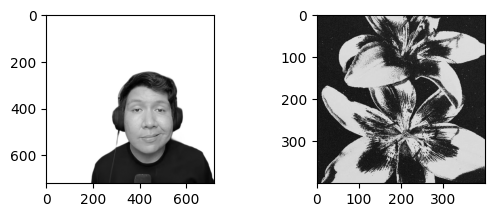

In [167]:
wdh = cv.imread("Windut.png", cv.IMREAD_GRAYSCALE)
bng = cv.imread("Bunga.png", cv.IMREAD_GRAYSCALE)
plt.subplot(2,2,1)
plt.imshow(wdh, cmap = "gray")
plt.subplot(2,2,2)
plt.imshow(bng, cmap = "gray")


C:\Users\ACER\AppData\Local\Temp\ipykernel_14108\2266044616.py:20: RuntimeWarning: overflow encountered in scalar subtract
  cek = abs(val - target[i])


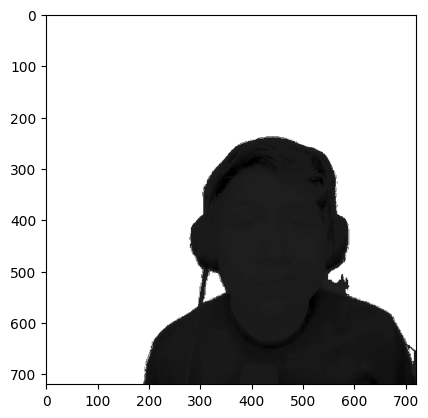

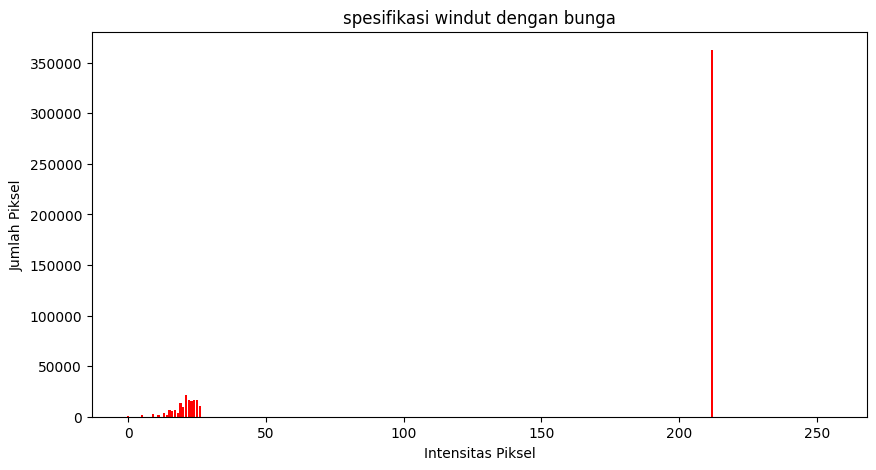

In [168]:
def histogram_equalization(image):
    hist = np.zeros(256, dtype=int)
    height, width = image.shape
    for i in range(height):
        for j in range(width):
            val = image[i, j]
            hist[val] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(hist[0:i+1])

    hasil = np.round(((cdf * 255) / (height * width)))
    return hasil.astype(np.uint8)

def cari_terdekat(val, target):
    min_diff = abs(val - target[0])
    min_index = 0
    for i in range(1, len(target)):
        cek = abs(val - target[i])
        if min_diff > cek:
            min_diff = cek
            min_index = i
    return min_index

def spesifikasi_histogram(source_image, target_image):
    citra_asal = histogram_equalization(source_image)
    citra_target = histogram_equalization(target_image)

    mapping = np.zeros(256, dtype=int)
    for i in range(256):
        mapping[i] = cari_terdekat(citra_asal[i], citra_target)

    height, width = source_image.shape
    hasil_spesifikasi = np.zeros_like(source_image)
    for i in range(height):
        for j in range(width):
            hasil_spesifikasi[i, j] = mapping[source_image[i, j]]

    return hasil_spesifikasi

windah2 = spesifikasi_histogram(wdh, bng)
whisto = buat_hist(windah2)
plt.imshow(windah2, cmap ="gray")
plot_histogram(whisto, "spesifikasi windut dengan bunga", "red")